In [1]:
import pandas as pd
df=pd.read_csv("/Users/anishjain/Downloads/large_inventory_demand_data.csv")
df.head()

,Date,Store_ID,Product_ID,Product_Category,Units_Sold,Price,Promotion,Stock_On_Hand
0,2024-01-01,S001,P0001,Furniture,89,79.96,No,328
1,2024-01-01,S001,P0002,Furniture,384,778.57,No,20
2,2024-01-01,S001,P0003,Toys,344,84.27,No,662
3,2024-01-01,S001,P0004,Furniture,239,964.00,Yes,755
4,2024-01-01,S001,P0005,Toys,232,793.52,Yes,889


In [2]:
df.tail()

,Date,Store_ID,Product_ID,Product_Category,Units_Sold,Price,Promotion,Stock_On_Hand
51995,2024-12-23,S010,P0096,Electronics,124,806.57,No,268
51996,2024-12-23,S010,P0097,Clothing,389,538.05,No,639
51997,2024-12-23,S010,P0098,Furniture,109,86.53,Yes,121
51998,2024-12-23,S010,P0099,Clothing,347,181.06,No,588
51999,2024-12-23,S010,P0100,Grocery,493,89.65,Yes,506


In [3]:
df.isnull().sum()

Date                0
Store_ID            0
Product_ID          0
Product_Category    0
Units_Sold          0
Price               0
Promotion           0
Stock_On_Hand       0
dtype: int64

In [4]:
df['Store_ID'] = df['Store_ID'].str.extract(r'(\d+)')

In [5]:
df['Product_ID'] = df['Product_ID'].str.extract(r'(\d+)')

In [7]:
df['Product_Category'].unique()

array(['Furniture', 'Toys', 'Grocery', 'Electronics', 'Clothing'],
      dtype=object)

In [7]:
df['Product_Category'] = df['Product_Category'].map({'Furniture': 1, 'Toys': 2,'Grocery': 3,'Electronics':4,'Clothing':5})


In [8]:
df['Promotion'] = df['Promotion'].map({'Yes': 1, 'No': 0})

In [9]:
df.head()

,Date,Store_ID,Product_ID,Product_Category,Units_Sold,Price,Promotion,Stock_On_Hand
0,2024-01-01,001,0001,1,89,79.96,0,328
1,2024-01-01,001,0002,1,384,778.57,0,20
2,2024-01-01,001,0003,2,344,84.27,0,662
3,2024-01-01,001,0004,1,239,964.00,1,755
4,2024-01-01,001,0005,2,232,793.52,1,889


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Define features and target
features = df[['Store_ID', 'Product_ID', 'Product_Category', 'Units_Sold', 'Price',
               'Stock_On_Hand']]
Y = df['Promotion']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features, Y, test_size=0.2, random_state=42)

# Train a classification model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.53      0.51      5177
           1       0.51      0.48      0.49      5223

    accuracy                           0.50     10400
   macro avg       0.50      0.50      0.50     10400
weighted avg       0.50      0.50      0.50     10400

Accuracy: 0.5026923076923077


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logreg_model = LogisticRegression(max_iter=5000, solver='lbfgs', C=10)
logreg_model.fit(X_train_scaled, y_train)
logreg_pred = logreg_model.predict(X_test_scaled)

# Evaluation
print("----- Logistic Regression Model -----")
print("Accuracy:", accuracy_score(y_test, logreg_pred))
print("Classification Report:\n", classification_report(y_test, logreg_pred))


----- Logistic Regression Model -----
Accuracy: 0.4998076923076923
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.55      0.52      5177
           1       0.50      0.45      0.48      5223

    accuracy                           0.50     10400
   macro avg       0.50      0.50      0.50     10400
weighted avg       0.50      0.50      0.50     10400



In [13]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)
print("Accuracy:", accuracy_score(y_test,y_pred))

Mean Squared Error (MSE): 0.49817307692307694
R² Score: -0.9927312927090923
Accuracy: 0.5018269230769231


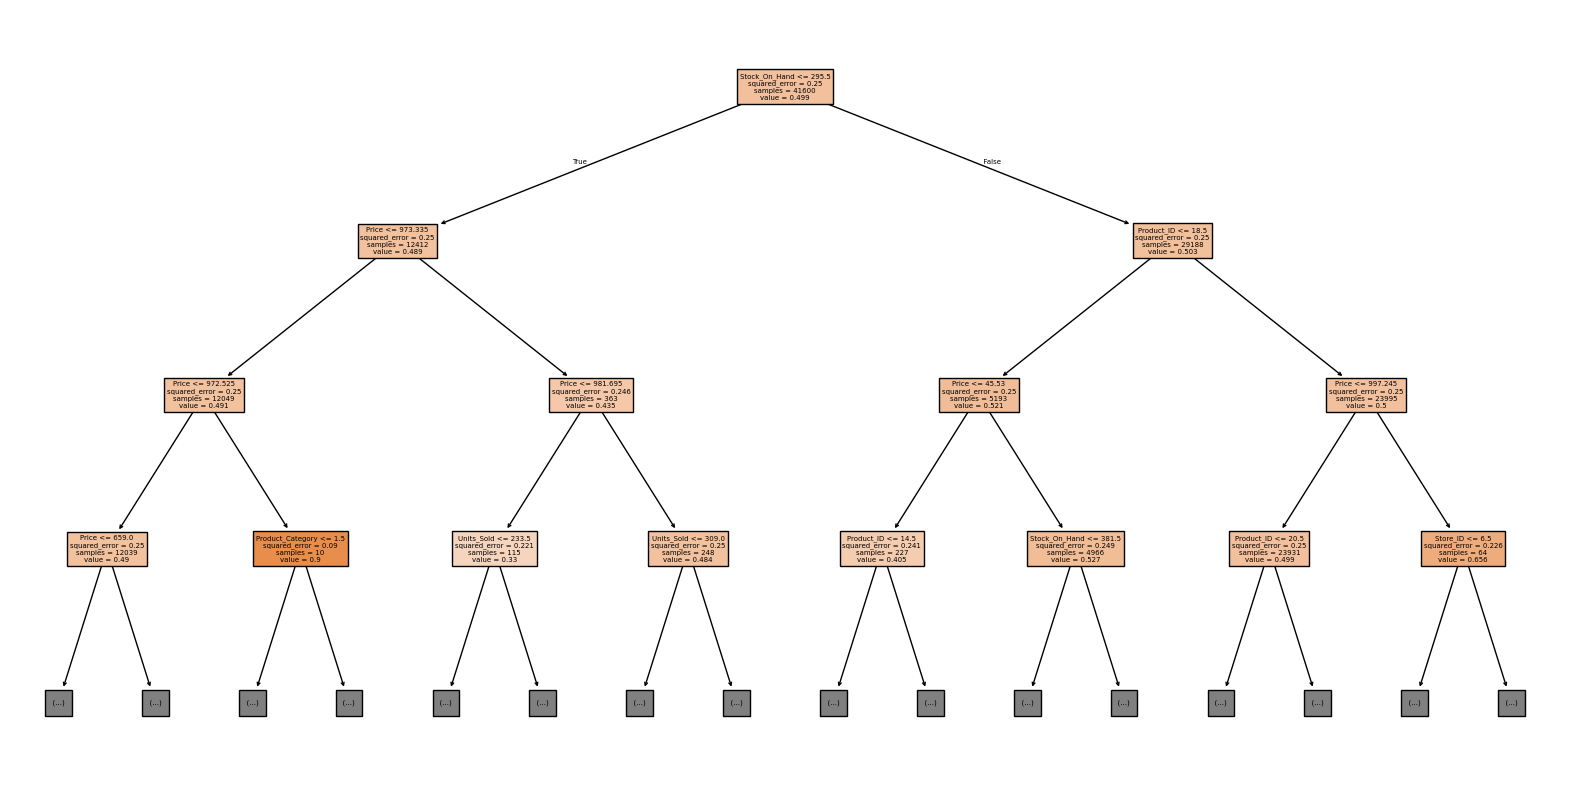

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=features.columns, filled=True, max_depth=3)
plt.show()
